In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile
import shutil

In [5]:
years = range(2016, 2025)

url_templates = {
    "FARS": "https://static.nhtsa.gov/nhtsa/downloads/FARS/{year}/National/FARS{year}NationalCSV.zip",
    "CRSS": "https://static.nhtsa.gov/nhtsa/downloads/CRSS/{year}/CRSS{year}CSV.zip",
}

Path("raw_zips").mkdir(exist_ok=True)

for dataset, template in url_templates.items():
    for year in years:
        year_dir = Path(dataset) / str(year)
        year_dir.mkdir(parents=True, exist_ok=True)

        zip_path = Path("raw_zips") / f"{dataset}_{year}.zip"
        url = template.format(year=year)

        print(f"Downloading {dataset} {year}...")
        urlretrieve(url, zip_path)

        print(f"Extracting {dataset} {year}...")
        with ZipFile(zip_path, "r") as z:
            z.extractall(year_dir)

        print(f"Organizing {dataset} {year}...")
        for csv_path in list(year_dir.rglob("*")):
            if csv_path.is_file() and csv_path.suffix.lower() == ".csv":
                target = year_dir / csv_path.name.lower()

                if csv_path.resolve() != target.resolve():
                    if target.exists():
                        target.unlink()
                    shutil.move(str(csv_path), str(target))
                elif csv_path.name != csv_path.name.lower():
                    csv_path.rename(target)

        for folder in sorted(year_dir.rglob("*"), reverse=True):
            if folder.is_dir():
                try:
                    folder.rmdir()
                except OSError:
                    pass

print("Done.")

Extracting FARS 2016...
Organizing FARS 2016...
Extracting FARS 2017...
Organizing FARS 2017...
Extracting FARS 2018...
Organizing FARS 2018...
Extracting FARS 2019...
Organizing FARS 2019...
Extracting FARS 2020...
Organizing FARS 2020...
Extracting FARS 2021...
Organizing FARS 2021...
Extracting FARS 2022...
Organizing FARS 2022...
Extracting FARS 2023...
Organizing FARS 2023...
Extracting FARS 2024...
Organizing FARS 2024...
Extracting CRSS 2016...
Organizing CRSS 2016...
Extracting CRSS 2017...
Organizing CRSS 2017...
Extracting CRSS 2018...
Organizing CRSS 2018...
Extracting CRSS 2019...
Organizing CRSS 2019...
Extracting CRSS 2020...
Organizing CRSS 2020...
Extracting CRSS 2021...
Organizing CRSS 2021...
Extracting CRSS 2022...
Organizing CRSS 2022...
Extracting CRSS 2023...
Organizing CRSS 2023...
Extracting CRSS 2024...
Organizing CRSS 2024...
Done.


In [6]:
for dataset in ["FARS", "CRSS"]:
    for year in range(2016, 2025):
        year_dir = Path(dataset) / str(year)
        print(
            dataset,
            year,
            "accident:", (year_dir / "accident.csv").exists(),
            "vehicle:", (year_dir / "vehicle.csv").exists(),
            "person:", (year_dir / "person.csv").exists()
        )

FARS 2016 accident: False vehicle: False person: False
FARS 2017 accident: False vehicle: False person: False
FARS 2018 accident: False vehicle: False person: False
FARS 2019 accident: False vehicle: False person: False
FARS 2020 accident: False vehicle: False person: False
FARS 2021 accident: False vehicle: False person: False
FARS 2022 accident: False vehicle: False person: False
FARS 2023 accident: False vehicle: False person: False
FARS 2024 accident: False vehicle: False person: False
CRSS 2016 accident: False vehicle: False person: False
CRSS 2017 accident: False vehicle: False person: False
CRSS 2018 accident: False vehicle: False person: False
CRSS 2019 accident: False vehicle: False person: False
CRSS 2020 accident: False vehicle: False person: False
CRSS 2021 accident: False vehicle: False person: False
CRSS 2022 accident: False vehicle: False person: False
CRSS 2023 accident: False vehicle: False person: False
CRSS 2024 accident: False vehicle: False person: False


In [10]:
def make_dataset(meta_folder, sub_folder):
    # Read the same CSV table across all years and add a consistent YEAR column.
    years = range(2016, 2025)
    dfs = []

    for year in years:
        year_df = pd.read_csv(
            f"{meta_folder}/{year}/{sub_folder}",
            encoding="latin-1",
            low_memory=False
        )
        year_df["YEAR"] = int(year)
        dfs.append(year_df)

    return pd.concat(dfs, ignore_index=True)

fars_accidents = make_dataset("FARS", "accident.csv")
fars_vehicles = make_dataset("FARS", "vehicle.csv")
fars_persons = make_dataset("FARS", "person.csv")

crss_accidents = make_dataset("CRSS", "accident.csv")
crss_vehicles = make_dataset("CRSS", "vehicle.csv")
crss_persons = make_dataset("CRSS", "person.csv")


In [11]:
datasets = [fars_accidents, fars_vehicles, fars_persons, 
crss_accidents, crss_persons, crss_vehicles]
for df in datasets:
    df.columns = df.columns.str.upper().str.strip()

In [12]:
fars_accidents = fars_accidents[["ST_CASE",
                                 "YEAR",
                                 "MONTH",
                                 "DAY_WEEK",
                                 "HOUR",
                                 "STATE",
                                 "COUNTY",
                                 "CITY",
                                 "LATITUDE",
                                 "LONGITUD",
                                 "FATALS",
                                 "RUR_URB",
                                 "WEATHER",
                                 "LGT_COND"]]
fars_vehicles = fars_vehicles[["ST_CASE",
                                "YEAR",
                               "VEH_NO",
                               "BODY_TYP",
                               "DR_DRINK",
                               "SPEEDREL"]]

fars_persons = fars_persons[[
    "ST_CASE",
    "YEAR",
    "VEH_NO",
    "PER_NO",
    "PER_TYP",
    "AGE",
    "SEX",
    "DRINKING",
    "ALC_RES",
    "INJ_SEV"
]]

crss_accidents = crss_accidents[[
    "CASENUM", #instead of ST_CASE as seen in FARS    
    "YEAR",
    "MONTH",
    "DAY_WEEK",
    "HOUR",
    "MINUTE",  
    "WEIGHT",                
    "VE_TOTAL",       
    "PERMVIT",        
    "PERNOTMVIT",     
    "NUM_INJ",        
    "MAX_SEV",        
    "LGT_COND",
    "WEATHER",
    "ALCOHOL",        
    "URBANICITY"
]]

crss_vehicles = crss_vehicles[[
    "CASENUM", 
    "YEAR",
    "VEH_NO",
    "BODY_TYP",
    "SPEEDREL"
]]

crss_persons = crss_persons[[
    "CASENUM",
    "YEAR",
    "VEH_NO",
    "PER_NO",
    "PER_TYP",
    "AGE",
    "SEX",
    "DRINKING",
    "ALC_RES",
    "INJ_SEV"
]]

In [13]:
assert fars_persons.columns.tolist().count("DRINKING") == 1

In [14]:
# Merge FARS person, vehicle, and accident tables.
# YEAR is included in the merge keys to avoid accidental cross-year matches.
fars = fars_persons.merge(
    fars_vehicles,
    on=["ST_CASE", "YEAR", "VEH_NO"],
    how="left"
)

fars_full = fars.merge(
    fars_accidents,
    on=["ST_CASE", "YEAR"],
    how="left"
)


In [15]:
# Merge CRSS person, vehicle, and accident tables.
# YEAR is included in the merge keys to avoid accidental cross-year matches.
crss = crss_persons.merge(
    crss_vehicles,
    on=["CASENUM", "YEAR", "VEH_NO"],
    how="left"
)

crss_full = crss.merge(
    crss_accidents,
    on=["CASENUM", "YEAR"],
    how="left"
)


In [16]:
fars_full.columns

Index(['ST_CASE', 'YEAR', 'VEH_NO', 'PER_NO', 'PER_TYP', 'AGE', 'SEX',
       'DRINKING', 'ALC_RES', 'INJ_SEV', 'BODY_TYP', 'DR_DRINK', 'SPEEDREL',
       'MONTH', 'DAY_WEEK', 'HOUR', 'STATE', 'COUNTY', 'CITY', 'LATITUDE',
       'LONGITUD', 'FATALS', 'RUR_URB', 'WEATHER', 'LGT_COND'],
      dtype='str')

In [17]:
crss_full.columns

Index(['CASENUM', 'YEAR', 'VEH_NO', 'PER_NO', 'PER_TYP', 'AGE', 'SEX',
       'DRINKING', 'ALC_RES', 'INJ_SEV', 'BODY_TYP', 'SPEEDREL', 'MONTH',
       'DAY_WEEK', 'HOUR', 'MINUTE', 'WEIGHT', 'VE_TOTAL', 'PERMVIT',
       'PERNOTMVIT', 'NUM_INJ', 'MAX_SEV', 'LGT_COND', 'WEATHER', 'ALCOHOL',
       'URBANICITY'],
      dtype='str')

In [18]:
#scooter periods
crss_full["YEAR"] = pd.to_numeric(crss_full["YEAR"], errors="coerce")
fars_full["YEAR"] = pd.to_numeric(fars_full["YEAR"], errors="coerce")

crss_full["PERIOD"] = crss_full["YEAR"].apply(lambda x: "pre_scooter" if x <= 2017 
                                    else "post_scooter")
fars_full["PERIOD"] = fars_full["YEAR"].apply(lambda x: "pre_scooter" if x <= 2017 
                                    else "post_scooter")

In [19]:
#DUI thresholds - creates a boolean column if the row has the 
# given values for at least 1 of the 3 columns

invalid_bac = [995, 996, 997, 998, 999]
crss_full["ALC_RES_CLEAN"] = crss_full["ALC_RES"].replace(invalid_bac, np.nan)
crss_full["DUI"] = (
    (crss_full["ALCOHOL"] == 1) |
    (crss_full["DRINKING"] == 1) |
    (crss_full["ALC_RES_CLEAN"] >= 80)
).astype(int)
fars_full["ALC_RES_CLEAN"] = fars_full["ALC_RES"].replace(invalid_bac, np.nan)
fars_full["DUI"] = (
    (fars_full["DR_DRINK"] == 1) |
    (fars_full["DRINKING"] == 1) |
    (fars_full["ALC_RES_CLEAN"] > 0)
).astype(int)

In [20]:
#temporal bins
bins = [0, 3, 6, 9, 12, 15, 18, 21, 24]
labels = ["Late Night", "Early Morning", "Morning", "Late Morning",
          "Afternoon", "Late Afternoon", "Evening", "Night"]
crss_full["HOUR_BIN"] = pd.cut(crss_full["HOUR"], bins=bins, labels=labels, right=False)
crss_full["HOUR"] = crss_full["HOUR"].apply(lambda x: np.nan if x>24 else x)
fars_full["HOUR_BIN"] = pd.cut(fars_full["HOUR"], bins = bins, labels=labels, right=False)
fars_full["HOUR"] = fars_full["HOUR"].apply(lambda x: np.nan if x>24 else x)

In [21]:
crss_dui = crss_full[crss_full["DUI"]==1]
fars_dui = fars_full[fars_full["DUI"]==1]

In [22]:
crss_prop_period = pd.crosstab(
    index=crss_full["PERIOD"],
    columns=crss_full["DUI"],
    normalize="index" #period bars in total add up to 1, broken down by DUI or not
)
fars_prop_period = pd.crosstab(
    index=fars_full["PERIOD"],
    columns=fars_full["DUI"],
    normalize="index"
)


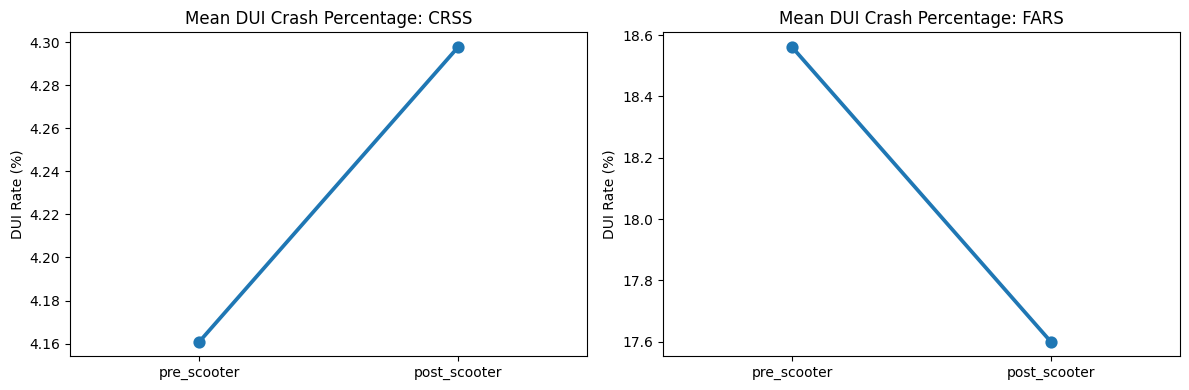

In [23]:
order = ["pre_scooter", "post_scooter"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

rate_crss = crss_full.groupby("PERIOD")["DUI"].mean().reset_index()
rate_crss["DUI_pct"] = rate_crss["DUI"] * 100

sns.pointplot(data=rate_crss, x="PERIOD", y="DUI_pct", order=order, ax=axes[0])
axes[0].set_title("Mean DUI Crash Percentage: CRSS")
axes[0].set_ylabel("DUI Rate (%)")
axes[0].set_xlabel("")

rate_fars = fars_full.groupby("PERIOD")["DUI"].mean().reset_index()
rate_fars["DUI_pct"] = rate_fars["DUI"] * 100

sns.pointplot(data=rate_fars, x="PERIOD", y="DUI_pct", order=order, ax=axes[1])
axes[1].set_title("Mean DUI Crash Percentage: FARS")
axes[1].set_ylabel("DUI Rate (%)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

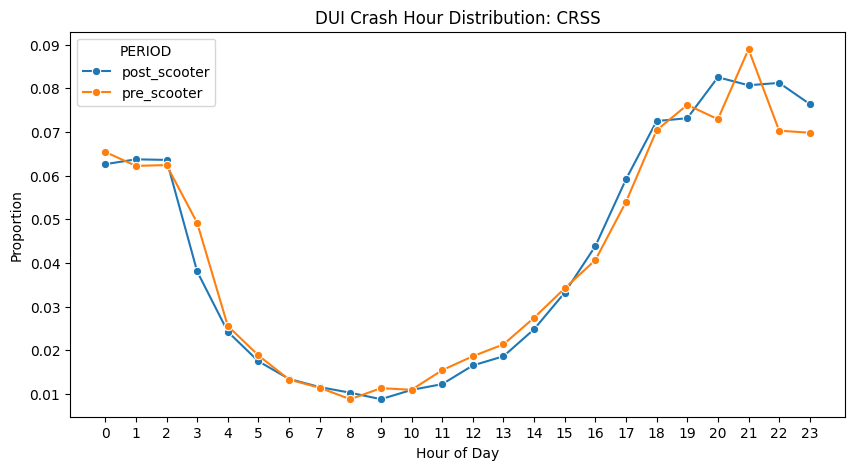

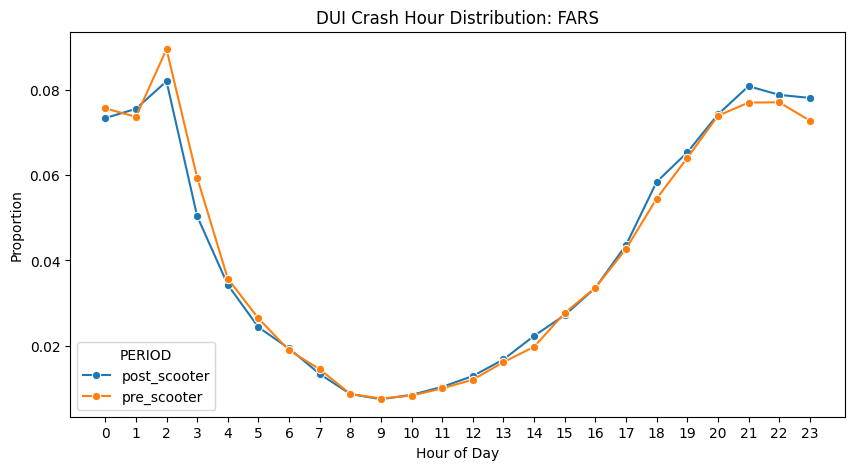

In [24]:
def plot_hour_dist(df, title):
    hour_dist = (
        df.dropna(subset=["HOUR"])
        .groupby(["PERIOD", "HOUR"])
        .size()
        .groupby(level=0)
        .transform(lambda x: x / x.sum())
        .reset_index(name="prop")
    )

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=hour_dist, x="HOUR", y="prop", hue="PERIOD", marker="o")
    plt.title(title)
    plt.ylabel("Proportion")
    plt.xlabel("Hour of Day")
    plt.xticks(range(0, 24))
    plt.show()

plot_hour_dist(crss_dui, "DUI Crash Hour Distribution: CRSS")
plot_hour_dist(fars_dui, "DUI Crash Hour Distribution: FARS")

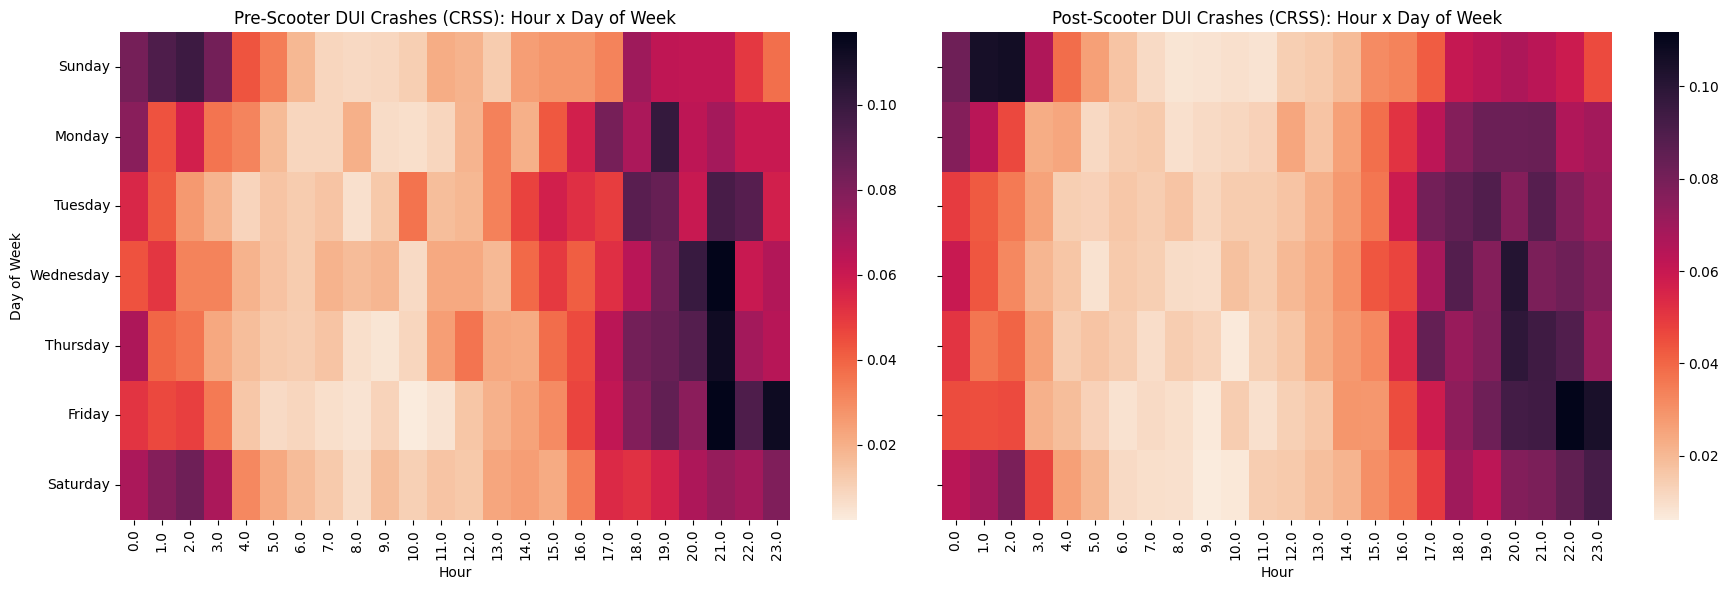

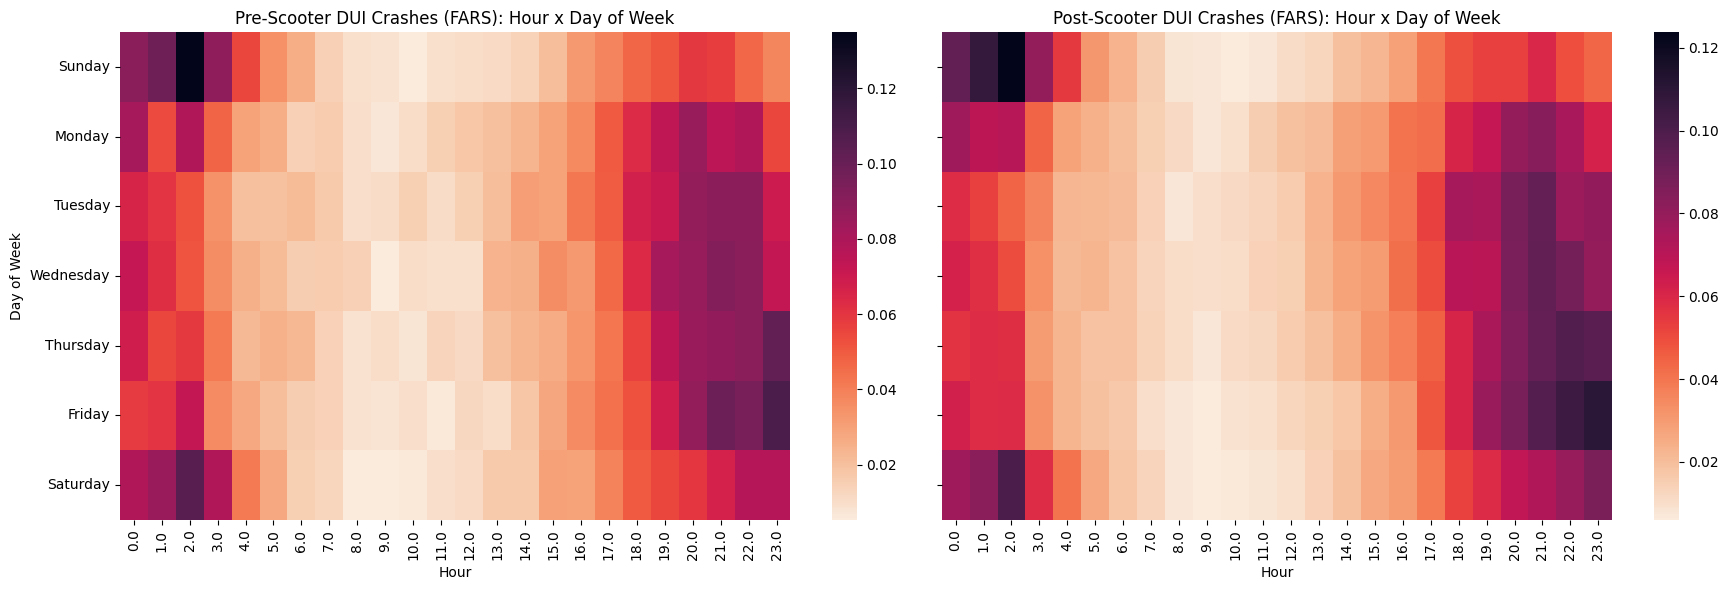

In [25]:
day_map = {
    1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday",
    5: "Thursday", 6: "Friday", 7: "Saturday"
}

def make_heatmap_pair(df, source):
    pre = df[df["PERIOD"] == "pre_scooter"]
    post = df[df["PERIOD"] == "post_scooter"]

    heat_pre = pre.groupby(["DAY_WEEK", "HOUR"]).size().unstack(fill_value=0)
    heat_post = post.groupby(["DAY_WEEK", "HOUR"]).size().unstack(fill_value=0)

    heat_pre.index = heat_pre.index.map(day_map)
    heat_post.index = heat_post.index.map(day_map)

    heat_pre = heat_pre.div(heat_pre.sum(axis=1), axis=0)
    heat_post = heat_post.div(heat_post.sum(axis=1), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

    sns.heatmap(heat_pre, cmap="rocket_r", ax=axes[0])
    axes[0].set_title(f"Pre-Scooter DUI Crashes ({source}): Hour x Day of Week")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Day of Week")

    sns.heatmap(heat_post, cmap="rocket_r", ax=axes[1])
    axes[1].set_title(f"Post-Scooter DUI Crashes ({source}): Hour x Day of Week")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

make_heatmap_pair(crss_dui.dropna(subset=["HOUR"]), "CRSS")
make_heatmap_pair(fars_dui.dropna(subset=["HOUR"]), "FARS")

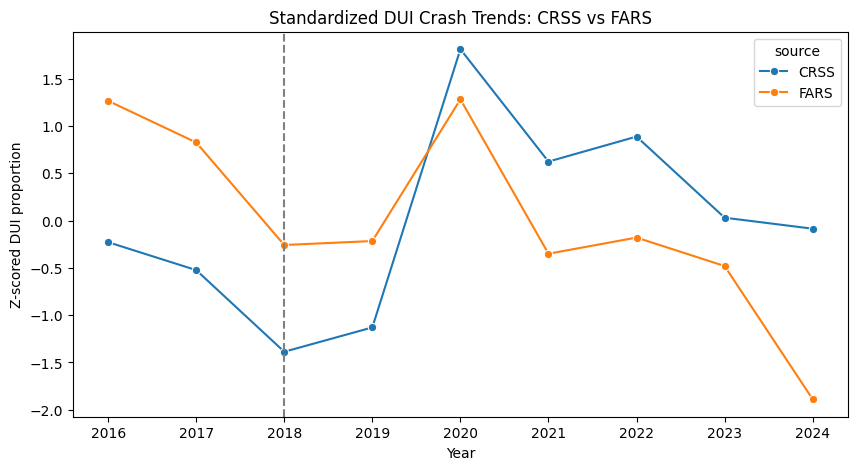

In [26]:
yearly_crss = (
    crss_full
    .groupby("YEAR")["DUI"]
    .mean()
    .reset_index()
)
yearly_fars = (
    fars_full
    .groupby("YEAR")["DUI"]
    .mean()
    .reset_index()
)

yearly_crss["source"] = "CRSS"
yearly_fars["source"] = "FARS"
combined = pd.concat([yearly_crss, yearly_fars])

combined["DUI_z"] = (
    combined.groupby("source")["DUI"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=combined, x="YEAR", y="DUI_z", hue="source", marker="o")
plt.axvline(2018, linestyle="--", color="gray")
plt.title("Standardized DUI Crash Trends: CRSS vs FARS")
plt.ylabel("Z-scored DUI proportion")
plt.xlabel("Year")
plt.xticks(range(2016, 2025))
plt.show()

In [29]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

<!-- inserted-stat-analysis -->

**Statistical modeling setup.** This cell imports the statistical tools used for the formal analysis. `statsmodels` is used for generalized linear models, and `chi2_contingency` is used to test whether the hourly distribution of DUI crashes differs between the pre- and post-2018 periods.


In [30]:
# NHTSA uses these values as special missing/unknown BAC codes.
INVALID_BAC = [995, 996, 997, 998, 999]

def clean_hour(s):
    # Convert hour values to numeric and keep only valid hours from 0 to 23.
    h = pd.to_numeric(s, errors="coerce")
    return h.where((h >= 0) & (h <= 23), np.nan)

def clean_bac(s):
    # Convert BAC values to numeric and replace invalid NHTSA codes with NaN.
    b = pd.to_numeric(s, errors="coerce")
    return b.where(~b.isin(INVALID_BAC), np.nan)


<!-- inserted-stat-analysis -->

**Cleaning helper variables.** This cell standardizes two variables that are used repeatedly in the analysis. Invalid hour values are converted to missing values, and special NHTSA BAC codes such as 995-999 are treated as missing rather than real alcohol measurements.


In [31]:
def make_crash_level_fars(fars_accidents, fars_vehicles, fars_persons):
    # Work on copies so the original EDA dataframes remain unchanged.
    acc = fars_accidents.copy()
    veh = fars_vehicles.copy()
    per = fars_persons.copy()

    # Standardize column names in case some files use inconsistent capitalization.
    for df in [acc, veh, per]:
        df.columns = df.columns.str.upper().str.strip()

    # Clean basic accident-level time variables.
    acc["HOUR"] = clean_hour(acc["HOUR"])
    acc["MONTH"] = pd.to_numeric(acc["MONTH"], errors="coerce")
    acc["DAY_WEEK"] = pd.to_numeric(acc["DAY_WEEK"], errors="coerce")

    # FARS vehicle-level DUI flag: DR_DRINK == 1 means drinking was reported for the driver.
    veh["DR_DRINK"] = pd.to_numeric(veh["DR_DRINK"], errors="coerce")
    veh_dui = (
        veh.assign(veh_dui=veh["DR_DRINK"].eq(1))
        .groupby(["ST_CASE", "YEAR"], as_index=False)["veh_dui"]
        .max()
    )

    # FARS person-level DUI flag: drinking reported or valid BAC >= 0.08.
    per["DRINKING"] = pd.to_numeric(per["DRINKING"], errors="coerce")
    per["ALC_RES_CLEAN"] = clean_bac(per["ALC_RES"])
    per["per_dui"] = per["DRINKING"].eq(1) | per["ALC_RES_CLEAN"].ge(80)
    per_dui = (
        per.groupby(["ST_CASE", "YEAR"], as_index=False)["per_dui"]
        .max()
    )

    # Merge DUI indicators back to the accident table so each row is one crash.
    full = (
        acc.merge(veh_dui, on=["ST_CASE", "YEAR"], how="left")
        .merge(per_dui, on=["ST_CASE", "YEAR"], how="left")
    )

    # A crash is DUI-related if either vehicle-level or person-level evidence indicates DUI.
    full["veh_dui"] = full["veh_dui"].fillna(False)
    full["per_dui"] = full["per_dui"].fillna(False)
    full["DUI"] = (full["veh_dui"] | full["per_dui"]).astype(int)

    # Nighttime is defined as 10 PM to 2 AM, based on the EDA's late-night DUI pattern.
    full["NIGHT"] = full["HOUR"].isin([22, 23, 0, 1, 2]).astype(int)

    # FARS is a census of fatal crashes, so each crash receives weight 1.
    full["WEIGHT"] = 1.0
    return full

def make_crash_level_crss(crss_accidents, crss_persons):
    # CRSS is sample-based, so we keep the crash weight from the accident table.
    acc = crss_accidents.copy()
    per = crss_persons.copy()

    for df in [acc, per]:
        df.columns = df.columns.str.upper().str.strip()

    # Clean accident-level variables and preserve CRSS sampling weights.
    acc["HOUR"] = clean_hour(acc["HOUR"])
    acc["MONTH"] = pd.to_numeric(acc["MONTH"], errors="coerce")
    acc["DAY_WEEK"] = pd.to_numeric(acc["DAY_WEEK"], errors="coerce")
    acc["ALCOHOL"] = pd.to_numeric(acc["ALCOHOL"], errors="coerce")
    acc["WEIGHT"] = pd.to_numeric(acc["WEIGHT"], errors="coerce").fillna(1.0)

    # CRSS person-level DUI flag: drinking reported or valid BAC >= 0.08.
    per["DRINKING"] = pd.to_numeric(per["DRINKING"], errors="coerce")
    per["ALC_RES_CLEAN"] = clean_bac(per["ALC_RES"])
    per["per_dui"] = per["DRINKING"].eq(1) | per["ALC_RES_CLEAN"].ge(80)
    per_dui = (
        per.groupby(["CASENUM", "YEAR"], as_index=False)["per_dui"]
        .max()
    )

    # Merge person-level DUI evidence onto one crash-level row per CASENUM.
    full = acc.merge(per_dui, on=["CASENUM", "YEAR"], how="left")
    full["per_dui"] = full["per_dui"].fillna(False)

    # CRSS DUI flag uses accident-level ALCOHOL plus person-level evidence.
    full["DUI"] = (full["ALCOHOL"].eq(1) | full["per_dui"]).astype(int)
    full["NIGHT"] = full["HOUR"].isin([22, 23, 0, 1, 2]).astype(int)
    return full

# Build the two crash-level datasets used for statistical testing.
fars_crash = make_crash_level_fars(fars_accidents, fars_vehicles, fars_persons)
crss_crash = make_crash_level_crss(crss_accidents, crss_persons)

print("FARS crash-level rows:", fars_crash.shape)
print("CRSS crash-level rows:", crss_crash.shape)


FARS crash-level rows: (325922, 19)
CRSS crash-level rows: (468993, 19)


<!-- inserted-stat-analysis -->

**Crash-level dataset construction.** This cell converts the analysis from person-level records to crash-level records. This is necessary because the research question asks whether a crash is DUI-related, not whether an individual person record is DUI-related. A crash is coded as DUI-related if any available alcohol-related indicator suggests alcohol involvement. The cell also creates a nighttime indicator for crashes between 10 PM and 2 AM, which captures the late-night period where DUI crashes are most concentrated.


In [32]:
for df in [fars_crash, crss_crash]:
    df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
    df["HOUR"] = pd.to_numeric(df["HOUR"], errors="coerce")

<!-- inserted-stat-analysis -->

**Type standardization.** This cell makes sure `YEAR` and `HOUR` are numeric in both crash-level datasets. This prevents errors when comparing years, defining pre/post periods, sorting hours, or creating hourly contingency tables.


In [33]:
def make_monthly(df):
    # Keep rows with valid year and month, then create time variables.
    x = df.dropna(subset=["YEAR", "MONTH"]).copy()
    x["YEAR"] = pd.to_numeric(x["YEAR"], errors="coerce")
    x["MONTH"] = pd.to_numeric(x["MONTH"], errors="coerce")

    # month_id is a continuous time trend from Jan 2016 onward.
    x["month_id"] = (x["YEAR"] - 2016) * 12 + x["MONTH"]

    # post is the main predictor: 0 for 2016-2017, 1 for 2018-2024.
    x["post"] = (x["YEAR"] >= 2018).astype(int)

    # COVID years are controlled separately because 2020-2021 disrupted driving patterns.
    x["covid"] = x["YEAR"].isin([2020, 2021]).astype(int)

    # Weighted counts are needed because CRSS is sample-based.
    x["dui_w"] = x["WEIGHT"] * x["DUI"]
    x["night_dui_w"] = x["WEIGHT"] * x["DUI"] * x["NIGHT"]

    # Aggregate to one row per month.
    g = x.groupby(["YEAR", "MONTH", "month_id", "post", "covid"], as_index=False).agg(
        total=("WEIGHT", "sum"),
        dui=("dui_w", "sum"),
        night_dui=("night_dui_w", "sum"),
        sample_n=("DUI", "size"),
    )

    # These are the monthly response variables used in the models.
    g["dui_prop"] = g["dui"] / g["total"]
    g["night_prop_among_dui"] = g["night_dui"] / g["dui"].replace(0, np.nan)
    return g

crss_monthly = make_monthly(crss_crash)
fars_monthly = make_monthly(fars_crash)

<!-- inserted-stat-analysis -->

**Monthly aggregation.** This cell aggregates crash-level records into monthly totals. Monthly aggregation makes the data appropriate for time-based statistical models and avoids treating each individual crash as fully independent in a national time-series setting. For CRSS, totals are weighted using the CRSS sampling weight because CRSS is a sample-based dataset. FARS is treated as an unweighted census of fatal crashes.


In [34]:
fars_monthly

,YEAR,MONTH,month_id,post,covid,total,dui,night_dui,sample_n,dui_prop,night_prop_among_dui
0,2016,1,1,0,0,2354.0,784.0,265.0,2354,0.333050,0.338010
1,2016,2,2,0,0,2426.0,807.0,298.0,2426,0.332646,0.369269
2,2016,3,3,0,0,2694.0,897.0,339.0,2694,0.332962,0.377926
3,2016,4,4,0,0,2713.0,906.0,340.0,2713,0.333948,0.375276
4,2016,5,5,0,0,3005.0,1019.0,401.0,3005,0.339101,0.393523
...,...,...,...,...,...,...,...,...,...,...,...
103,2024,8,104,1,0,3342.0,958.0,360.0,3342,0.286655,0.375783
104,2024,9,105,1,0,3277.0,971.0,350.0,3277,0.296308,0.360453
105,2024,10,106,1,0,3369.0,933.0,348.0,3369,0.276937,0.372990
106,2024,11,107,1,0,3077.0,811.0,280.0,3077,0.263568,0.345253


## Fit Regression Models

This runs three statistical models for each dataset. The first tests whether the DUI proportion changed after 2018. The second models monthly DUI counts with an offset for total crashes. The third tests whether the nighttime share of DUI crashes changed after 2018.

In [35]:
def fit_stat_models(g, source):
    g = g.copy()
    g["MONTH"] = g["MONTH"].astype(int)

    # Model 1: Binomial GLM for the monthly proportion of crashes that are DUI-related.
    dui_prop_model = smf.glm(
        "dui_prop ~ post + month_id + covid + C(MONTH)",
        data=g,
        family=sm.families.Binomial(),
        var_weights=g["total"],
    ).fit(cov_type="HC1")

    # Model 2: Poisson count/rate model for monthly DUI crashes.
    # The offset adjusts for the total number of crashes in each month.
    dui_count_model = smf.glm(
        "dui ~ post + month_id + covid + C(MONTH)",
        data=g,
        family=sm.families.Poisson(),
        offset=np.log(g["total"]),
    ).fit(cov_type="HC1")

    # Model 3: Binomial GLM for whether DUI crashes became more concentrated at night.
    timing_data = g.dropna(subset=["night_prop_among_dui"]).copy()
    night_timing_model = smf.glm(
        "night_prop_among_dui ~ post + month_id + covid + C(MONTH)",
        data=timing_data,
        family=sm.families.Binomial(),
        var_weights=timing_data["dui"],
    ).fit(cov_type="HC1")

    # Extract the post-2018 effect from each model.
    rows = []
    for name, model, effect_name in [
        ("DUI proportion model", dui_prop_model, "odds_ratio"),
        ("DUI count/rate model", dui_count_model, "rate_ratio"),
        ("Nighttime DUI timing model", night_timing_model, "odds_ratio"),
    ]:
        coef = model.params["post"]
        ci = model.conf_int().loc["post"]
        rows.append({
            "source": source,
            "model": name,
            effect_name: np.exp(coef),
            "ci_low": np.exp(ci[0]),
            "ci_high": np.exp(ci[1]),
            "p_value": model.pvalues["post"],
            "overdispersion": model.pearson_chi2 / model.df_resid,
        })

    return pd.DataFrame(rows)

# Combine CRSS and FARS results into one table.
model_results = pd.concat([
    fit_stat_models(crss_monthly, "CRSS"),
    fit_stat_models(fars_monthly, "FARS"),
], ignore_index=True)

model_results

,source,model,odds_ratio,ci_low,ci_high,p_value,overdispersion,rate_ratio
0,CRSS,DUI proportion model,0.892489,0.821790,0.969270,0.006909,332.678603,NaN
1,CRSS,DUI count/rate model,NaN,0.828008,0.970448,0.006918,319.398207,0.896403
2,CRSS,Nighttime DUI timing model,1.041686,0.906159,1.197482,0.565768,225.724059,NaN
3,FARS,DUI proportion model,0.990303,0.960653,1.020869,0.529825,1.683633,NaN
4,FARS,DUI count/rate model,NaN,0.973182,1.014585,0.550071,1.164501,0.993668
5,FARS,Nighttime DUI timing model,0.986559,0.941530,1.033740,0.570198,1.392238,NaN


<!-- inserted-stat-analysis -->

**Regression model interpretation.** This cell fits three complementary models. The binomial proportion model tests whether the share of crashes that are DUI-related changed after 2018. The Poisson model tests monthly DUI crash counts while using total crashes as an exposure offset. The nighttime timing model tests whether DUI crashes became more or less concentrated between 10 PM and 2 AM. The models control for a monthly time trend, seasonality through calendar-month fixed effects, and a COVID-period indicator for 2020-2021.


## Descriptive Pre/Post Summary

This prints the raw descriptive differences between the pre-scooter and post-scooter periods. These values help interpret the regression results in plain language.


In [36]:
def pre_post_summary(g):
    return g.groupby("post").apply(
        lambda d: pd.Series({
            "dui_prop": d["dui"].sum() / d["total"].sum(),
            "night_prop_among_dui": d["night_dui"].sum() / d["dui"].sum(),
            "total_crashes": d["total"].sum(),
            "dui_crashes": d["dui"].sum(),
            "night_dui_crashes": d["night_dui"].sum(),
        }),
        include_groups=False,
    )

print("CRSS")
display(pre_post_summary(crss_monthly))

print("FARS")
display(pre_post_summary(fars_monthly))


CRSS


,dui_prop,night_prop_among_dui,total_crashes,dui_crashes,night_dui_crashes
post,,,,,
0,0.040068,0.370059,1.327341e+07,5.318352e+05,196810.148657
1,0.039192,0.373482,4.309313e+07,1.688902e+06,630773.667392


FARS


,dui_prop,night_prop_among_dui,total_crashes,dui_crashes,night_dui_crashes
post,,,,,
0,0.322070,0.370442,69308.0,22322.0,8269.0
1,0.308339,0.367765,256614.0,79124.0,29099.0


<!-- inserted-stat-analysis -->

**Descriptive pre/post comparison.** This table summarizes the raw differences between the pre-2018 and post-2018 periods. It is useful for interpreting the regression results in plain language, but it should not be treated as causal evidence because the periods may differ in many other ways besides scooter availability.


## Logistic Regression: Post-2018 Nighttime Interaction

This model tests whether the post-2018 period is associated with a different change in DUI likelihood for late-night crashes compared with non-late-night crashes.


In [39]:
def fit_night_interaction_model(df, source):
    x = df.copy()

    x["YEAR"] = pd.to_numeric(x["YEAR"], errors="coerce")
    x["MONTH"] = pd.to_numeric(x["MONTH"], errors="coerce")
    x["DUI"] = pd.to_numeric(x["DUI"], errors="coerce")
    x["NIGHT"] = pd.to_numeric(x["NIGHT"], errors="coerce")

    x = x.dropna(subset=["YEAR", "MONTH", "DUI", "NIGHT", "WEIGHT"])

    x["post"] = (x["YEAR"] >= 2018).astype(int)
    x["covid"] = x["YEAR"].isin([2020, 2021]).astype(int)
    x["month_id"] = (x["YEAR"] - 2016) * 12 + x["MONTH"]
    x["MONTH"] = x["MONTH"].astype(int)

    model = smf.glm(
        "DUI ~ post * NIGHT + month_id + covid + C(MONTH)",
        data=x,
        family=sm.families.Binomial(),
        freq_weights=x["WEIGHT"],
    ).fit(cov_type="HC1")

    coef = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    results = pd.DataFrame({
        "source": source,
        "term": coef.index,
        "coef": coef.values,
        "odds_ratio": np.exp(coef.values),
        "ci_lower": np.exp(conf[0].values),
        "ci_upper": np.exp(conf[1].values),
        "p_value": pvals.values,
    })

    return model, results


crss_night_model, crss_night_results = fit_night_interaction_model(crss_crash, "CRSS")
fars_night_model, fars_night_results = fit_night_interaction_model(fars_crash, "FARS")

night_interaction_results = pd.concat(
    [crss_night_results, fars_night_results],
    ignore_index=True
)

night_interaction_results[
    night_interaction_results["term"].isin(["post", "NIGHT", "post:NIGHT"])
]

,source,term,coef,odds_ratio,ci_lower,ci_upper,p_value
12,CRSS,post,-0.101800,0.903210,0.898327,0.908120,1.543062e-296
13,CRSS,NIGHT,1.985221,7.280655,7.237474,7.324093,0.000000e+00
14,CRSS,post:NIGHT,-0.035180,0.965432,0.958881,0.972028,4.202108e-24
29,FARS,post,0.035206,1.035833,1.004576,1.068063,2.432167e-02
30,FARS,NIGHT,1.407088,4.084047,3.929837,4.244309,0.000000e+00
31,FARS,post:NIGHT,-0.147024,0.863273,0.826752,0.901408,2.623116e-11


### Interpretation

The key term in this model is `post:NIGHT`. This interaction term tests whether the post-2018 change in DUI likelihood is different for nighttime crashes compared with non-nighttime crashes.

If the interaction odds ratio is greater than 1, nighttime crashes became relatively more likely to be DUI-related after 2018 compared with non-nighttime crashes. If the odds ratio is less than 1, nighttime crashes became relatively less likely to be DUI-related after 2018. If the p-value is greater than 0.05, there is not strong statistical evidence that the nighttime DUI pattern changed differently after 2018.

## Chi-Square Test for Hourly Distribution

This tests whether the distribution of DUI crashes across the 24 hours of the day differs between the pre-2018 and post-2018 periods.

In [37]:
def chi_square_hour_distribution(df, source):
    # Keep only DUI crashes with valid hour values.
    x = df[(df["DUI"] == 1) & df["HOUR"].notna()].copy()

    # Convert YEAR and HOUR to numeric so the pre/post comparison and hour columns work reliably.
    x["YEAR"] = pd.to_numeric(x["YEAR"], errors="coerce")
    x["HOUR"] = pd.to_numeric(x["HOUR"], errors="coerce")
    x = x.dropna(subset=["YEAR", "HOUR"])

    x["period"] = np.where(x["YEAR"] >= 2018, "post", "pre")

    # Build a weighted period-by-hour contingency table.
    table = x.pivot_table(
        index="period",
        columns="HOUR",
        values="WEIGHT",
        aggfunc="sum",
        fill_value=0,
    )

    # Ensure all 24 hours appear as columns, even if an hour has zero crashes.
    for h in range(24):
        if h not in table.columns:
            table[h] = 0
    table = table[range(24)]

    # Chi-square test: are pre and post hourly distributions statistically different?
    chi2, p, dof, expected = chi2_contingency(table)
    return pd.Series({
        "source": source,
        "chi2": chi2,
        "dof": dof,
        "p_value": p,
    })

pd.DataFrame([
    chi_square_hour_distribution(crss_crash, "CRSS"),
    chi_square_hour_distribution(fars_crash, "FARS"),
])


,source,chi2,dof,p_value
0,CRSS,4049.929014,23,0.000000
1,FARS,54.526208,23,0.000227


<!-- inserted-stat-analysis -->

**Chi-square hourly distribution test.** This cell formally tests whether DUI crashes are distributed differently across the 24 hours of the day in the pre- and post-2018 periods. This supports the EDA timing plots by checking whether the observed hourly patterns differ statistically, not just visually.


In [38]:
for _, row in model_results.iterrows():
    effect = row.get("odds_ratio", np.nan)
    effect_name = "odds ratio"

    if pd.isna(effect):
        effect = row.get("rate_ratio", np.nan)
        effect_name = "rate ratio"

    direction = "higher" if effect > 1 else "lower"
    significance = "statistically significant" if row["p_value"] < 0.05 else "not statistically significant"

    print(
        f"{row['source']} - {row['model']}: post-2018 {effect_name} = {effect:.3f}, "
        f"which suggests a {direction} post-2018 value; p = {row['p_value']:.3f}, "
        f"so this result is {significance} at the 0.05 level."
    )


CRSS - DUI proportion model: post-2018 odds ratio = 0.892, which suggests a lower post-2018 value; p = 0.007, so this result is statistically significant at the 0.05 level.
CRSS - DUI count/rate model: post-2018 rate ratio = 0.896, which suggests a lower post-2018 value; p = 0.007, so this result is statistically significant at the 0.05 level.
CRSS - Nighttime DUI timing model: post-2018 odds ratio = 1.042, which suggests a higher post-2018 value; p = 0.566, so this result is not statistically significant at the 0.05 level.
FARS - DUI proportion model: post-2018 odds ratio = 0.990, which suggests a lower post-2018 value; p = 0.530, so this result is not statistically significant at the 0.05 level.
FARS - DUI count/rate model: post-2018 rate ratio = 0.994, which suggests a lower post-2018 value; p = 0.550, so this result is not statistically significant at the 0.05 level.
FARS - Nighttime DUI timing model: post-2018 odds ratio = 0.987, which suggests a lower post-2018 value; p = 0.570, 

## Results Analysis
The statistical results generally support the patterns observed in the EDA. Across both CRSS and FARS, there is no strong evidence that DUI-related crashes increased after 2018 or that their late-night timing pattern meaningfully shifted during the post-scooter period.

In CRSS, the DUI proportion model produced a post-2018 odds ratio of about 0.89 with a p-value around 0.007. This indicates that the weighted proportion of police-reported crashes classified as DUI-related was slightly lower in the post-2018 period after controlling for time trend, seasonality, and COVID years. The Poisson count/rate model gave a similar result, with a rate ratio of about 0.90. Since both estimates are below 1, the CRSS results do not suggest an increase in DUI crash involvement after 2018.

However, the nighttime DUI timing model for CRSS was not statistically significant, with an odds ratio of about 1.04 and a p-value around 0.57. This means that, although DUI crashes remain concentrated during late-night hours, there is no clear evidence that the share of DUI crashes occurring between 10 PM and 2 AM changed after 2018. In other words, the timing pattern appears stable across the pre- and post-scooter periods.

The FARS results show even less evidence of a post-2018 change. The DUI proportion model, Poisson count/rate model, and nighttime timing model all produced post-period estimates close to 1 and were not statistically significant. This suggests that fatal DUI crash patterns remained broadly stable across the study period. The lack of a significant post-period effect in FARS is consistent with the EDA, where the pre- and post-period curves and heatmaps showed similar late-night DUI patterns.

The chi-square tests provide additional evidence about timing distributions. These tests compare whether DUI-related crashes are distributed differently across the 24 hours of the day before and after 2018. While large datasets can produce statistically significant chi-square results even for small differences, the EDA plots show that the overall pattern remains similar: DUI crashes are consistently most concentrated during late-night hours, especially around weekend nightlife periods.

Overall, the results do not support the idea that the post-2018 period was associated with an increase in DUI-related crashes or a major shift in DUI crash timing. If anything, CRSS shows a small decrease in DUI crash proportion, while FARS shows no meaningful change. These findings suggest that national DUI crash patterns remained relatively stable across the pre- and post-scooter periods.

Importantly, these results should not be interpreted as proving that shared e-scooter programs had no effect on DUI crashes. The analysis uses national crash data and a broad post-2018 indicator, not city-level scooter rollout data or a treatment-control design. Therefore, the results are best interpreted as descriptive evidence: within national CRSS and FARS crash data, we do not observe a clear post-2018 increase or timing shift in DUI-related crashes.
